<a href="https://colab.research.google.com/github/iagooleite/Calculo-Numerico/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade I Cálculo numérico - Erros numéricos em aplicações simples de biofluidodinâmica**

Iago da Silva Leite | RA: 185228

---



## **Parte A - Truncamento e Arredondamento**

Tabela de Resultados:

         x  n  Truncado  Ea (Trunc)  Er (Trunc)  E% (Trunc)  Arredondado   Ea (Arr)    Er (Arr)    E% (Arr)
   3.14159  0         3    0.141593   0.0450703     4.50703            3   0.141593   0.0450703     4.50703
   3.14159  1       3.1   0.0415927   0.0132394     1.32394          3.1  0.0415927   0.0132394     1.32394
   3.14159  2      3.14  0.00159265 0.000506956   0.0506956         3.14 0.00159265 0.000506956   0.0506956
   3.14159  3     3.141  0.00059265 0.000188646   0.0188646        3.142 0.00040735 0.000129664   0.0129664
   3.14159  4    3.1415   9.265e-05 2.94914e-05  0.00294914       3.1416   7.35e-06 2.33958e-06 0.000233958
   98.7654  0        98     0.76543  0.00774998    0.774998           99    0.23457  0.00237502    0.237502
   98.7654  1      98.7     0.06543 0.000662479   0.0662479         98.8    0.03457 0.000350021   0.0350021
   98.7654  2     98.76     0.00543 5.49788e-05  0.00549788        98.77    0.00457 4.62713e-05  0.00462713
   98

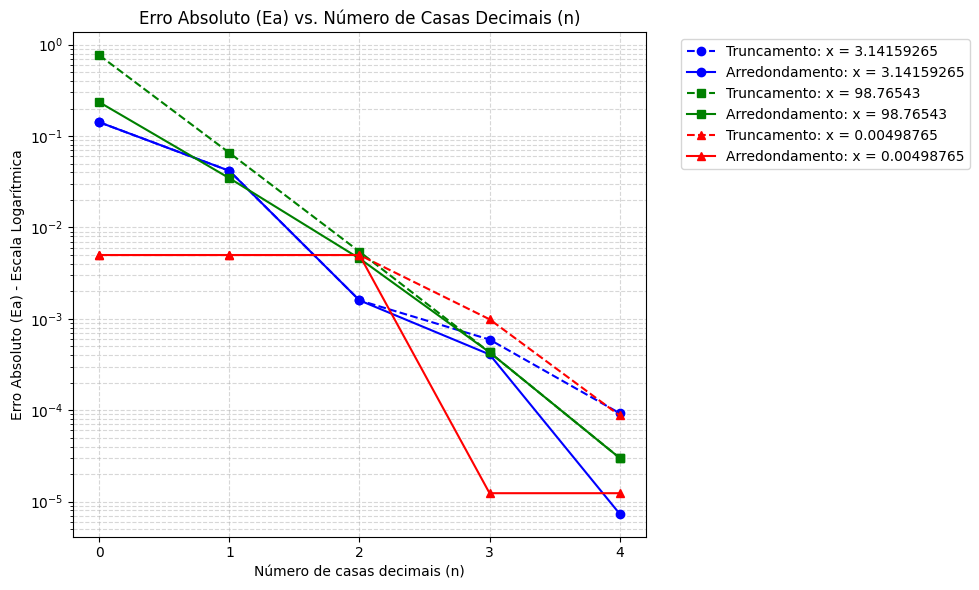

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# Valores fornecidos
x_valores = [3.14159265, 98.76543, 0.00498765]
n_valores = [0, 1, 2, 3, 4]

# Lista para armazenar os resultados
resultados = []

# Função auxiliar para truncamento
def truncar(valor, n):
    fator = 10.0 ** n
    return math.trunc(valor * fator) / fator

# Cálculo das aproximações e dos erros
for x in x_valores:
    for n in n_valores:
        # Truncamento
        x_trunc = truncar(x, n)
        ea_trunc = abs(x - x_trunc)              # Erro Absoluto
        er_trunc = ea_trunc / abs(x)             # Erro Relativo
        ep_trunc = er_trunc * 100                # Erro Percentual

        # Arredondamento
        x_round = round(x, n)
        ea_round = abs(x - x_round)
        er_round = ea_round / abs(x)
        ep_round = er_round * 100

        # Guardando os dados
        resultados.append({
            'x': x,
            'n': n,
            'Truncado': x_trunc,
            'Ea (Trunc)': ea_trunc,
            'Er (Trunc)': er_trunc,
            'E% (Trunc)': ep_trunc,
            'Arredondado': x_round,
            'Ea (Arr)': ea_round,
            'Er (Arr)': er_round,
            'E% (Arr)': ep_round
        })

# Organizando os resultados em uma tabela
df = pd.DataFrame(resultados)

# Exibindo a tabela formatada
print("Tabela de Resultados:\n")
print(df.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

# Gráfico em escala logarítmica de Ea em função de n
plt.figure(figsize=(10, 6))

cores = ['blue', 'green', 'red']
marcadores = ['o', 's', '^']

for i, x in enumerate(x_valores):
    df_x = df[df['x'] == x]

    # Plotando o erro de Truncamento (linha tracejada)
    plt.plot(df_x['n'], df_x['Ea (Trunc)'], marker=marcadores[i], linestyle='--',
             color=cores[i], label=f'Truncamento: x = {x}')

    # Plotando o erro de Arredondamento (linha contínua)
    plt.plot(df_x['n'], df_x['Ea (Arr)'], marker=marcadores[i], linestyle='-',
             color=cores[i], label=f'Arredondamento: x = {x}')

# Configurações do gráfico
plt.yscale('log') # Escala Logarítmica no eixo Y
plt.xlabel('Número de casas decimais (n)') # Número n de casas decimais no eixo X
plt.ylabel('Erro Absoluto (Ea) - Escala Logarítmica')
plt.title('Erro Absoluto (Ea) vs. Número de Casas Decimais (n)')
plt.xticks(n_valores)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar o gráfico
plt.show()

### **5.** Sim. O arredondamento sempre gera um erro absoluto menor ou igual ao erro gerado pelo truncamento. Como o truncamento apenas "corta" os dígitos restantes, o erro máximo pode ser de até $10^{-n}$. Já o arredondamento seleciona o valor representável mais próximo, limitando o erro máximo à metade desse intervalo, ou seja, $0,5 × 10^{-n}$.


---



## **Parte B – medidas de pressão arterial**


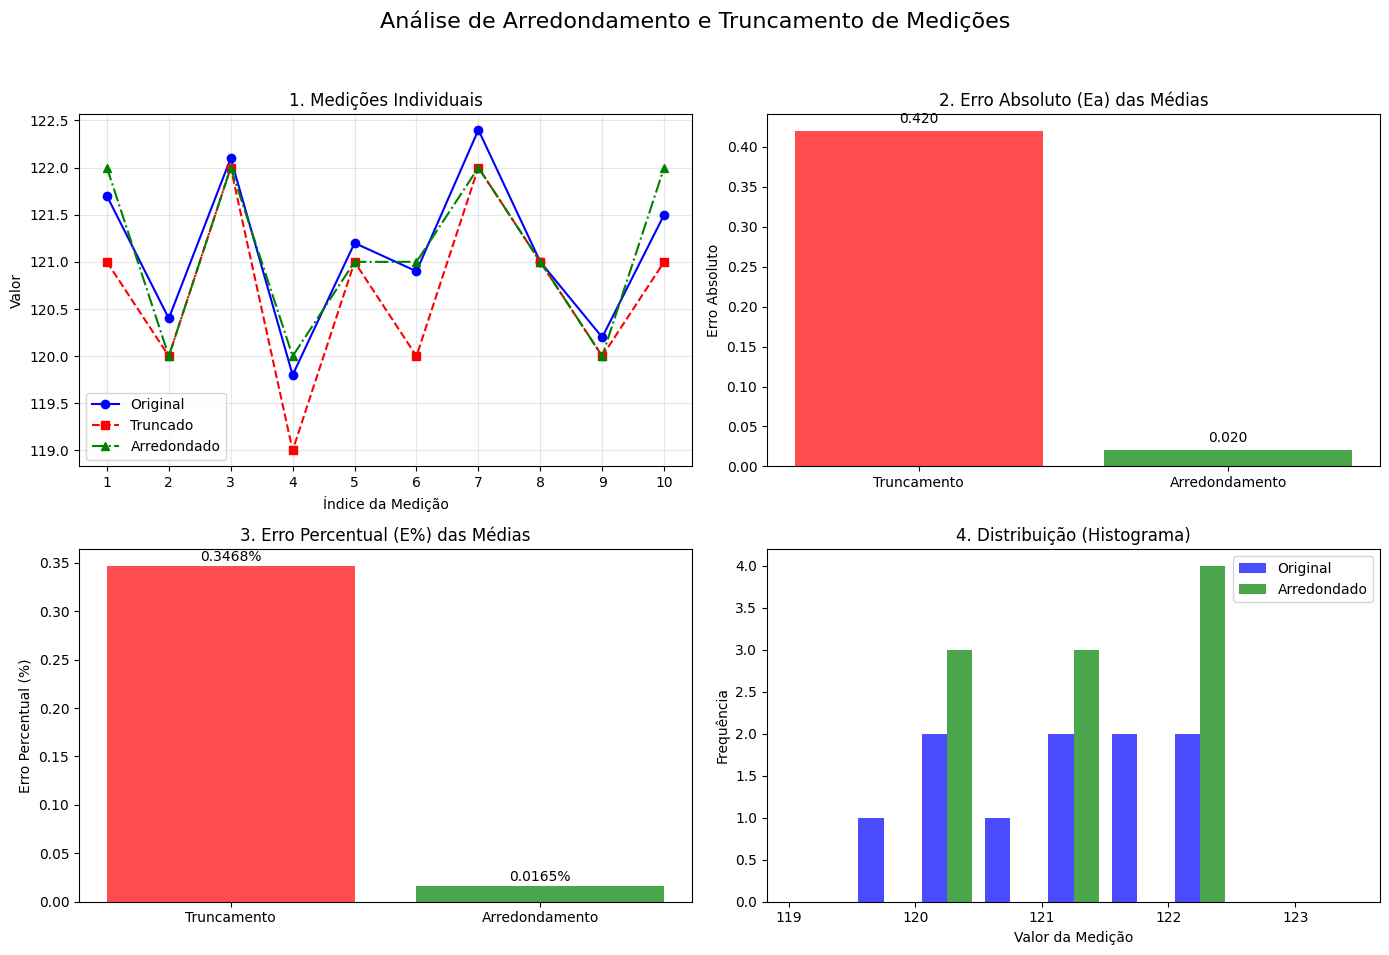

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np

# Medidas fornecidas
medidas = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

# Medidas truncadas
medidas_trunc = []

# Medida arredondada
medidas_arr = []

# Trunca todas as medidas
medidas_trunc = [math.trunc(m) for m in medidas]

# Arredonda todas as medidas
medidas_arr = [round(m) for m in medidas]

def calculos_estatisticos(dado):
    minimo = min(dado)
    maximo = max(dado)
    amplitude = maximo - minimo
    media = statistics.mean(dado)          # Alterado de 'dados' para 'dado'
    desvio_padrao = statistics.stdev(dado) # Alterado de 'dados' para 'dado'

    # Retorna os resultados organizados em um dicionário
    return {
        "Mínimo": minimo,
        "Máximo": maximo,
        "Amplitude": amplitude,
        "Média": media,
        "Desvio Padrão": desvio_padrao
    }

# Aplicando a função para todas as listas e armazenando os resultados
resultados_originais = calculos_estatisticos(medidas)
resultados_truncados = calculos_estatisticos(medidas_trunc)
resultados_arredondados = calculos_estatisticos(medidas_arr)

def calcular_erros(media_ref, media_aprox):
    # Erro Absoluto (Ea)
    ea = abs(media_ref - media_aprox)

    # Erro Relativo (Er)
    er = ea / abs(media_ref)

    # Erro Percentual (E%)
    ep = er * 100

    # Retornando os resultados organizados
    return {
        "Erro Absoluto (Ea)": ea,
        "Erro Relativo (Er)": er,
        "Erro Percentual (E%)": ep
    }

# Pegamos as médias que calculamos antes
media_original = resultados_originais["Média"]
media_truncada = resultados_truncados["Média"]
media_arredondada = resultados_arredondados["Média"]

# Calculamos os erros
erros_truncamento = calcular_erros(media_original, media_truncada)
erros_arredondamento = calcular_erros(media_original, media_arredondada)

# Extraindo os erros dos dicionários para facilitar a plotagem
ea_trunc = erros_truncamento["Erro Absoluto (Ea)"]
ea_arr = erros_arredondamento["Erro Absoluto (Ea)"]

ep_trunc = erros_truncamento["Erro Percentual (E%)"]
ep_arr = erros_arredondamento["Erro Percentual (E%)"]

# Configuração do Painel de Gráficos (2 linhas, 2 colunas)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Arredondamento e Truncamento de Medições', fontsize=16)

# Gráfico 1: As 10 medições
x = np.arange(1, 11)
axs[0, 0].plot(x, medidas, marker='o', label='Original', color='blue')
axs[0, 0].plot(x, medidas_trunc, marker='s', linestyle='--', label='Truncado', color='red')
axs[0, 0].plot(x, medidas_arr, marker='^', linestyle='-.', label='Arredondado', color='green')

axs[0, 0].set_title('1. Medições Individuais')
axs[0, 0].set_xlabel('Índice da Medição')
axs[0, 0].set_ylabel('Valor')
axs[0, 0].set_xticks(x)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Erros Absolutos das Médias
categorias = ['Truncamento', 'Arredondamento']
erros_abs = [ea_trunc, ea_arr]
cores = ['red', 'green']

axs[0, 1].bar(categorias, erros_abs, color=cores, alpha=0.7)
axs[0, 1].set_title('2. Erro Absoluto (Ea) das Médias')
axs[0, 1].set_ylabel('Erro Absoluto')
for i, v in enumerate(erros_abs):
    axs[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Gráfico 3: Erros Percentuais das Médias
erros_perc = [ep_trunc, ep_arr]

axs[1, 0].bar(categorias, erros_perc, color=cores, alpha=0.7)
axs[1, 0].set_title('3. Erro Percentual (E%) das Médias')
axs[1, 0].set_ylabel('Erro Percentual (%)')
for i, v in enumerate(erros_perc):
    axs[1, 0].text(i, v + 0.005, f'{v:.4f}%', ha='center')

# Gráfico 4: Histograma (Original vs Arredondado)
bins = np.arange(119, 124, 0.5)
axs[1, 1].hist([medidas, medidas_arr], bins=bins, label=['Original', 'Arredondado'], color=['blue', 'green'], alpha=0.7)
axs[1, 1].set_title('4. Distribuição (Histograma)')
axs[1, 1].set_xlabel('Valor da Medição')
axs[1, 1].set_ylabel('Frequência')
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **B.2 - 4.** Sobre a média, a representação inteira por arredondamento é suficiente e a preserva quase perfeitamente. Já o truncamento não é suficiente, pois empurra todos os números para baixo, resultando em uma média menor. Falando agora sobre variabilidade, a representação inteira não consegue preservar a variabilidade desta amostra, pois embora o arredondamento salve a média central, ele aglomera os dados em degraus inteiros abruptos. Analisando o histograma, podemos ver que a curva fluida original se transforma em blocos densos, alterando o desvio-padrão amostral e destruindo a sensibilidade matemática necessária para analisar variações tão pequenas.


---



## **Parte C – vazão em um tubo de pequeno diâmetro**

--- Resultados Parte C.1 ---
           Cenário      Q (Arr)  E% (Arr)    Q (Trunc)  E% (Trunc)
        Referência 2.757421e-07       0.0 2.757421e-07    0.000000
        r (1 casa) 2.757421e-07       0.0 2.757421e-07    0.000000
      mu (3 casas) 2.412743e-07      12.5 3.216991e-07   16.666667
     dp (centenas) 2.757421e-07       0.0 2.757421e-07    0.000000
Todas simulatâneas 2.412743e-07      12.5 3.216991e-07   16.666667


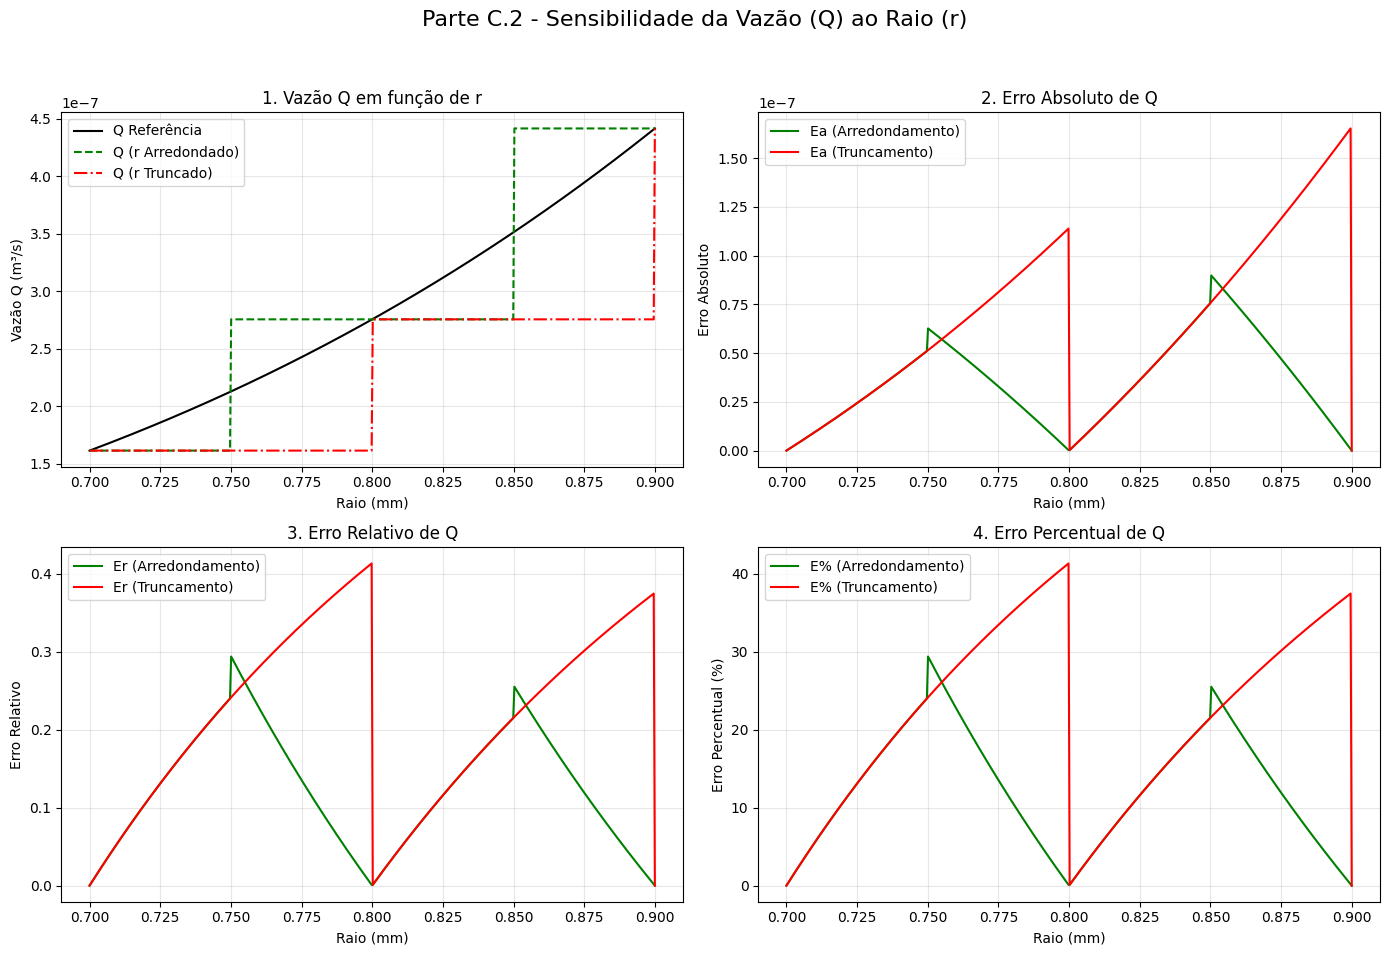

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Função de truncamento
def truncar(x, n):
    fator = 10.0 ** n
    return math.trunc(x * fator) / fator

def calcular_erros(ref, aprox):
    ea = abs(ref - aprox)
    er = ea / abs(ref) if ref != 0 else 0
    ep = er * 100
    return ea, er, ep

# Fórmula de Hagen-Poiseuille
def vazao_Q(r_m, mu, dp, L):
    return (math.pi * (r_m**4) * dp) / (8 * mu * L)

# Valores de referência
L = 0.20           # m
r_mm_ref = 0.80    # mm
mu_ref = 0.0035    # Pa.s (3.5 x 10^-3)
dp_ref = 1200.0    # Pa

# Q usando todos os valores fornecidos
Q_ref = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_ref, L)

# r arredondado e truncado para 1 casa decimal em mm
r_mm_arr = round(r_mm_ref, 1)
r_mm_trunc = truncar(r_mm_ref, 1)
Q_r_arr = vazao_Q(r_mm_arr * 1e-3, mu_ref, dp_ref, L)
Q_r_trunc = vazao_Q(r_mm_trunc * 1e-3, mu_ref, dp_ref, L)

# mu arredondada e truncada para 3 casas decimais em Pa.s
mu_arr = round(mu_ref, 3)
mu_trunc = truncar(mu_ref, 3)
Q_mu_arr = vazao_Q(r_mm_ref * 1e-3, mu_arr, dp_ref, L)
Q_mu_trunc = vazao_Q(r_mm_ref * 1e-3, mu_trunc, dp_ref, L)

# dp arredondada e truncada para centenas de pascal (n = -2)
dp_arr = round(dp_ref, -2)
dp_trunc = truncar(dp_ref, -2)
Q_dp_arr = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_arr, L)
Q_dp_trunc = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_trunc, L)

# Todas as aproximações simultaneamente
Q_todas_arr = vazao_Q(r_mm_arr * 1e-3, mu_arr, dp_arr, L)
Q_todas_trunc = vazao_Q(r_mm_trunc * 1e-3, mu_trunc, dp_trunc, L)

# Armazenando os resultados em uma lista para exibir na tabela
cenarios = [
    ("Referência", Q_ref, Q_ref),
    ("r (1 casa)", Q_r_arr, Q_r_trunc),
    ("mu (3 casas)", Q_mu_arr, Q_mu_trunc),
    ("dp (centenas)", Q_dp_arr, Q_dp_trunc),
    ("Todas simulatâneas", Q_todas_arr, Q_todas_trunc)
]

resultados_c1 = []
for nome, q_arr, q_trunc in cenarios:
    ea_arr, er_arr, ep_arr = calcular_erros(Q_ref, q_arr)
    ea_tr, er_tr, ep_tr = calcular_erros(Q_ref, q_trunc)

    resultados_c1.append({
        "Cenário": nome,
        "Q (Arr)": q_arr, "E% (Arr)": ep_arr,
        "Q (Trunc)": q_trunc, "E% (Trunc)": ep_tr
    })

df_c1 = pd.DataFrame(resultados_c1)
print("--- Resultados Parte C.1 ---")
print(df_c1.to_string(index=False))

# Valores de raio variando de 0.70 a 0.90 mm
raios_mm = np.linspace(0.70, 0.90, 500)

Q_refs = []
Q_arrs = []
Q_truncs = []

ea_arrs, er_arrs, ep_arrs = [], [], []
ea_truncs, er_truncs, ep_truncs = [], [], []

for r in raios_mm:
    q_ref = vazao_Q(r * 1e-3, mu_ref, dp_ref, L)

    r_a = round(r, 1)
    r_t = truncar(r, 1)

    q_a = vazao_Q(r_a * 1e-3, mu_ref, dp_ref, L)
    q_t = vazao_Q(r_t * 1e-3, mu_ref, dp_ref, L)

    Q_refs.append(q_ref)
    Q_arrs.append(q_a)
    Q_truncs.append(q_t)

    # Erros Arredondamento
    ea, er, ep = calcular_erros(q_ref, q_a)
    ea_arrs.append(ea)
    er_arrs.append(er)
    ep_arrs.append(ep)

    # Erros Truncamento
    ea, er, ep = calcular_erros(q_ref, q_t)
    ea_truncs.append(ea)
    er_truncs.append(er)
    ep_truncs.append(ep)

# Criando os gráficos solicitados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parte C.2 - Sensibilidade da Vazão (Q) ao Raio (r)', fontsize=16)

# Q em função de r
axs[0, 0].plot(raios_mm, Q_refs, label='Q Referência', color='black')
axs[0, 0].plot(raios_mm, Q_arrs, label='Q (r Arredondado)', linestyle='--', color='green')
axs[0, 0].plot(raios_mm, Q_truncs, label='Q (r Truncado)', linestyle='-.', color='red')
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio (mm)')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Erro absoluto de Q em função de r
axs[0, 1].plot(raios_mm, ea_arrs, label='Ea (Arredondamento)', color='green')
axs[0, 1].plot(raios_mm, ea_truncs, label='Ea (Truncamento)', color='red')
axs[0, 1].set_title('2. Erro Absoluto de Q')
axs[0, 1].set_xlabel('Raio (mm)')
axs[0, 1].set_ylabel('Erro Absoluto')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# Erro relativo de Q em função de r
axs[1, 0].plot(raios_mm, er_arrs, label='Er (Arredondamento)', color='green')
axs[1, 0].plot(raios_mm, er_truncs, label='Er (Truncamento)', color='red')
axs[1, 0].set_title('3. Erro Relativo de Q')
axs[1, 0].set_xlabel('Raio (mm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Erro percentual de Q em função de r
axs[1, 1].plot(raios_mm, ep_arrs, label='E% (Arredondamento)', color='green')
axs[1, 1].plot(raios_mm, ep_truncs, label='E% (Truncamento)', color='red')
axs[1, 1].set_title('4. Erro Percentual de Q')
axs[1, 1].set_xlabel('Raio (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **C.2 - 4.** Na equação de Hagen-Poiseuille, a vazão Q é diretamente proporcional ao raio elevado à quarta. Quando aplicamos pequenas variações, essa relaçao resulta em um grande aumento dos erros de entrada. Como demonstrado pela aproximação linear, o erro relativo da vazão é aproximadamente quatro vezes o erro relativo do raio. Isso significa que, se houver uma imprecisão geométrica ou de arredondamento de apenas 1% no valor de r, o cálculo final da vazão sofrerá um erro percentual de aproximadamente 4%.


---



## **Parte D – escoamento em um nanocateter**

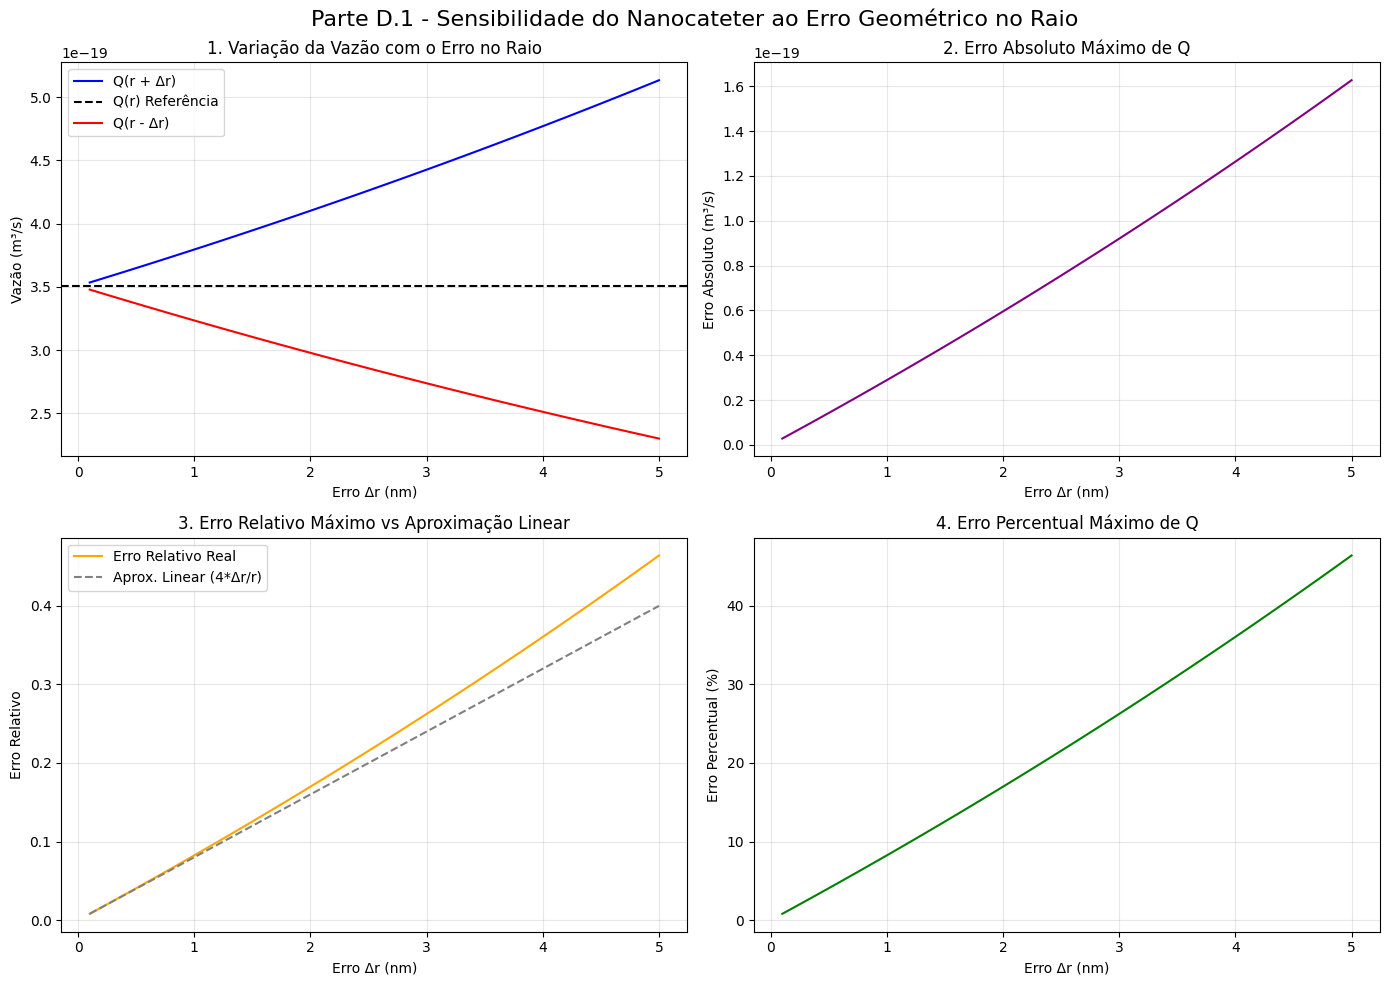


--- Parte D.2: Precisão Computacional (Numpy float32 vs float64) ---
Epsilon (float32): 1.1920928955078125e-07
Epsilon (float64): 2.220446049250313e-16

r^4 (float32): 6.2500003959774226e-30
r^4 (float64): 6.249999999999999e-30
Q (float32)  : 3.5062420652502925e-19
Q (float64)  : 3.506241800881465e-19
Diferença Absoluta: 2.643688274956116e-26
Diferença Relativa: 7.539948540604062e-08

--- Análise de Cancelamento para dr/r muito pequenos ---
Fator (dr/r)    | delta_1 (Direto)          | delta_2 (Avançado)       
----------------------------------------------------------------------
1.0e-04         | 0.00040006000399993       | 0.00040006000399995      
1.0e-06         | 0.00000400000600002       | 0.00000400000599976      
1.0e-08         | 0.00000004000000060       | 0.00000004000000042      
1.0e-10         | 0.00000000040000004       | 0.00000000040000003      
1.0e-12         | 0.00000000000400004       | 0.00000000000400036      
1.0e-14         | 0.00000000000004024       | 0.000

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros base do nanocateter
r = 50e-9          # raio em metros
L = 10e-6          # comprimento em metros
mu = 3.5e-3        # viscosidade em Pa.s
dp = 5000.0        # diferença de pressão em Pa

def vazao_Q(raio):
    return (np.pi * (raio**4) * dp) / (8 * mu * L)

Q_ref = vazao_Q(r)

# D.1 - Erro Geométrico

dr_nm = np.arange(0.1, 5.1, 0.1)
dr_m = dr_nm * 1e-9

Q_r_minus = []
Q_r_plus = []
ea_max = []
er_max = []
ep_max = []
aprox_linear = []

for dr in dr_m:
    q_minus = vazao_Q(r - dr)
    q_plus = vazao_Q(r + dr)

    Q_r_minus.append(q_minus)
    Q_r_plus.append(q_plus)

    # O erro máximo ocorre sempre para r+ devido ao expoente 4
    ea = max(abs(q_plus - Q_ref), abs(q_minus - Q_ref))
    er = ea / Q_ref
    ep = er * 100

    ea_max.append(ea)
    er_max.append(er)
    ep_max.append(ep)

    # Aproximação linear 4 * (dr/r)
    aprox_linear.append(4 * (dr / r))

# Gráficos da Parte D.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parte D.1 - Sensibilidade do Nanocateter ao Erro Geométrico no Raio', fontsize=16)

# Vazões
axs[0, 0].plot(dr_nm, Q_r_plus, label='Q(r + Δr)', color='blue')
axs[0, 0].axhline(y=Q_ref, color='black', linestyle='--', label='Q(r) Referência')
axs[0, 0].plot(dr_nm, Q_r_minus, label='Q(r - Δr)', color='red')
axs[0, 0].set_title('1. Variação da Vazão com o Erro no Raio')
axs[0, 0].set_xlabel('Erro Δr (nm)')
axs[0, 0].set_ylabel('Vazão (m³/s)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Erro Absoluto
axs[0, 1].plot(dr_nm, ea_max, color='purple')
axs[0, 1].set_title('2. Erro Absoluto Máximo de Q')
axs[0, 1].set_xlabel('Erro Δr (nm)')
axs[0, 1].set_ylabel('Erro Absoluto (m³/s)')
axs[0, 1].grid(True, alpha=0.3)

# Erro Relativo
axs[1, 0].plot(dr_nm, er_max, label='Erro Relativo Real', color='orange')
axs[1, 0].plot(dr_nm, aprox_linear, label='Aprox. Linear (4*Δr/r)', color='gray', linestyle='--')
axs[1, 0].set_title('3. Erro Relativo Máximo vs Aproximação Linear')
axs[1, 0].set_xlabel('Erro Δr (nm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Erro Percentual
axs[1, 1].plot(dr_nm, ep_max, color='green')
axs[1, 1].set_title('4. Erro Percentual Máximo de Q')
axs[1, 1].set_xlabel('Erro Δr (nm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# D.2 - Precisão Computacional

print("\n--- Parte D.2: Precisão Computacional (Numpy float32 vs float64) ---")

# Precisão da máquina
eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps
print(f"Epsilon (float32): {eps_32}")
print(f"Epsilon (float64): {eps_64}")

# Definição dos tipos
r_32 = np.float32(50e-9)
r_64 = np.float64(50e-9)

# Cálculo de r^4
r4_32 = r_32**4
r4_64 = r_64**4

# Cálculo de Q
const_32 = np.float32((np.pi * dp) / (8 * mu * L))
const_64 = np.float64((np.pi * dp) / (8 * mu * L))

Q_32 = const_32 * r4_32
Q_64 = const_64 * r4_64

# Diferenças
diff_abs = abs(Q_64 - Q_32)
diff_rel = diff_abs / Q_64

print(f"\nr^4 (float32): {r4_32}")
print(f"r^4 (float64): {r4_64}")
print(f"Q (float32)  : {Q_32}")
print(f"Q (float64)  : {Q_64}")
print(f"Diferença Absoluta: {diff_abs}")
print(f"Diferença Relativa: {diff_rel}")

# Análise de Perda de Significância
print("\n--- Análise de Cancelamento para dr/r muito pequenos ---")
print(f"{'Fator (dr/r)':<15} | {'delta_1 (Direto)':<25} | {'delta_2 (Avançado)':<25}")
print("-" * 70)

fatores_dr_r = [1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-15, 1e-16]

for fator in fatores_dr_r:
    dr_teste = r * fator

    # Forma 1: Pode sofrer cancelamento subtrativo
    delta_1 = (vazao_Q(r + dr_teste) - Q_ref) / Q_ref

    # Forma 2: Expansão algébrica
    delta_2 = (1 + fator)**4 - 1

    print(f"{fator:<15.1e} | {delta_1:<25.17f} | {delta_2:<25.17f}")

### **D.3.** A redução da escala geométrica para a ordem dos nanômetros provoca um aumento na razão entre a superfície e o volume do canal. Por conta dessa configuração espacial, os efeitos viscosos e as forças de interação do fluido com a parede sólida tornam-se consideravelmente mais importantes do que no escoamento macroscópico. Conforme ressaltado, a obtenção de um resultado com múltiplas casas decimais pode denotar precisão aritmética rigorosa, mas ainda assim ser fisicamente inadequada, visto que precisão numérica e validade do modelo são métricas completamente independentes. O uso da equação clássica de Hagen-Poiseuille nesta escala minúscula negligencia os fenômenos dominantes de interface e as dinâmicas moleculares específicas de nanocateteres.


---



## **Parte E – síntese visual**

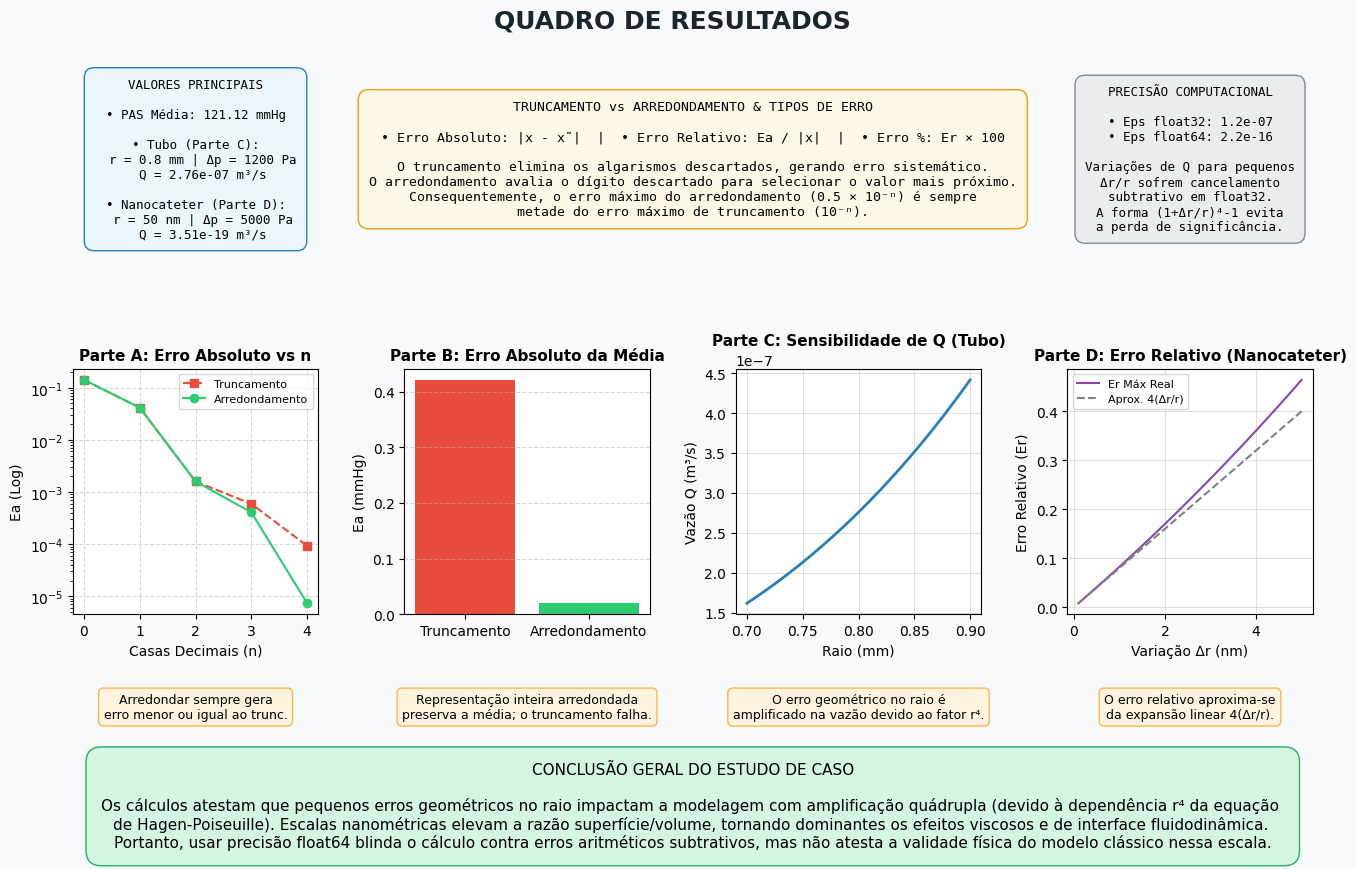

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# CÁLCULOS E PREPARAÇÃO DOS DADOS (PARTES A, B, C e D)

# PARTE A: Truncamento vs Arredondamento
x1 = 3.14159265
n_vals = [0, 1, 2, 3, 4]
ea_trunc_a = [abs(x1 - math.trunc(x1 * 10**n)/10**n) for n in n_vals]
ea_round_a = [abs(x1 - round(x1, n)) for n in n_vals]

# PARTE B: Pressão Arterial
pas = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
media_orig = np.mean(pas)
ea_tr_b = abs(media_orig - np.mean([math.trunc(m) for m in pas]))
ea_rd_b = abs(media_orig - np.mean([round(m) for m in pas]))

# PARTE C: Vazão no Tubo de Pequeno Diâmetro
L_c, mu_c, dp_c = 0.20, 3.5e-3, 1200.0
r_c_vals = np.linspace(0.7, 0.9, 100) # mm
Q_c_vals = (np.pi * ((r_c_vals*1e-3)**4) * dp_c) / (8 * mu_c * L_c)

# PARTE D: Nanocateter e Precisão Computacional
r_d, L_d, mu_d, dp_d = 50e-9, 10e-6, 3.5e-3, 5000.0
Q_d_ref = (np.pi * (r_d**4) * dp_d) / (8 * mu_d * L_d)

dr_nm = np.linspace(0.1, 5.0, 50)
er_max_d = []
for dr in (dr_nm * 1e-9):
    q_plus = (np.pi * ((r_d + dr)**4) * dp_d) / (8 * mu_d * L_d)
    er_max_d.append(abs(q_plus - Q_d_ref) / Q_d_ref)
aprox_lin_d = 4 * ((dr_nm * 1e-9) / r_d)

# Variáveis para o Cartão Float
eps32, eps64 = np.finfo(np.float32).eps, np.finfo(np.float64).eps

# Construção do quadro

# Figura com 16x10 polegadas a 100 DPI
fig = plt.figure(figsize=(16, 10), dpi=100)
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('QUADRO DE RESULTADOS',
             fontsize=18, fontweight='bold', color='#1A252C', y=0.96)

gs = gridspec.GridSpec(3, 4, figure=fig, height_ratios=[0.8, 1.4, 0.6], wspace=0.35, hspace=0.85)

# Cartões informativos

# Cartão 1 (Coluna 0)
ax_c1 = fig.add_subplot(gs[0, 0])
ax_c1.axis('off')
ax_c1.text(0.5, 0.5,
    "VALORES PRINCIPAIS\n\n"
    f"• PAS Média: {media_orig:.2f} mmHg\n\n"
    f"• Tubo (Parte C):\n"
    f"  r = 0.8 mm | Δp = 1200 Pa\n"
    f"  Q = {((np.pi * ((0.8e-3)**4) * dp_c) / (8 * mu_c * L_c)):.2e} m³/s\n\n"
    f"• Nanocateter (Parte D):\n"
    f"  r = 50 nm | Δp = 5000 Pa\n"
    f"  Q = {Q_d_ref:.2e} m³/s",
    transform=ax_c1.transAxes, ha='center', va='center', fontsize=9, fontfamily='monospace',
    bbox=dict(boxstyle="round,pad=0.8", facecolor='#EBF5FB', edgecolor='#2980B9'))

# Cartão 2 (Colunas 1 e 2)
ax_c2 = fig.add_subplot(gs[0, 1:3])
ax_c2.axis('off')
ax_c2.text(0.5, 0.5,
    "TRUNCAMENTO vs ARREDONDAMENTO & TIPOS DE ERRO\n\n"
    "• Erro Absoluto: |x - x̃|  |  • Erro Relativo: Ea / |x|  |  • Erro %: Er × 100\n\n"
    "O truncamento elimina os algarismos descartados, gerando erro sistemático.\n"
    "O arredondamento avalia o dígito descartado para selecionar o valor mais próximo.\n"
    "Consequentemente, o erro máximo do arredondamento (0.5 × 10⁻ⁿ) é sempre\n"
    "metade do erro máximo de truncamento (10⁻ⁿ).",
    transform=ax_c2.transAxes, ha='center', va='center', fontsize=9.5, fontfamily='monospace',
    bbox=dict(boxstyle="round,pad=0.8", facecolor='#FEF9E7', edgecolor='#F39C12'))

# Cartão 3 (Coluna 3)
ax_c3 = fig.add_subplot(gs[0, 3])
ax_c3.axis('off')
ax_c3.text(0.5, 0.5,
    "PRECISÃO COMPUTACIONAL\n\n"
    f"• Eps float32: {eps32:.1e}\n"
    f"• Eps float64: {eps64:.1e}\n\n"
    "Variações de Q para pequenos\n"
    "Δr/r sofrem cancelamento\n"
    "subtrativo em float32.\n"
    "A forma (1+Δr/r)⁴-1 evita\n"
    "a perda de significância.",
    transform=ax_c3.transAxes, ha='center', va='center', fontsize=9, fontfamily='monospace',
    bbox=dict(boxstyle="round,pad=0.8", facecolor='#EAEDED', edgecolor='#7F8C8D'))

# Gráficos com comentário da resposta
caixa_comentario = dict(boxstyle="round,pad=0.4", facecolor='#FFF3E0', edgecolor='#FFB74D')

# Gráfico Parte A
ax_a = fig.add_subplot(gs[1, 0])
ax_a.plot(n_vals, ea_trunc_a, 's--', color='#E74C3C', label='Truncamento')
ax_a.plot(n_vals, ea_round_a, 'o-', color='#2ECC71', label='Arredondamento')
ax_a.set_yscale('log')
ax_a.set_title('Parte A: Erro Absoluto vs n', fontsize=11, fontweight='bold')
ax_a.set_xlabel('Casas Decimais (n)')
ax_a.set_ylabel('Ea (Log)')
ax_a.grid(True, linestyle='--', alpha=0.5)
ax_a.legend(fontsize=8)
ax_a.text(0.5, -0.32, "Arredondar sempre gera\nerro menor ou igual ao trunc.",
          transform=ax_a.transAxes, ha='center', va='top', fontsize=9, bbox=caixa_comentario)

# Gráfico Parte B
ax_b = fig.add_subplot(gs[1, 1])
ax_b.bar(['Truncamento', 'Arredondamento'], [ea_tr_b, ea_rd_b], color=['#E74C3C', '#2ECC71'])
ax_b.set_title('Parte B: Erro Absoluto da Média', fontsize=11, fontweight='bold')
ax_b.set_ylabel('Ea (mmHg)')
ax_b.grid(axis='y', linestyle='--', alpha=0.5)
ax_b.text(0.5, -0.32, "Representação inteira arredondada\npreserva a média; o truncamento falha.",
          transform=ax_b.transAxes, ha='center', va='top', fontsize=9, bbox=caixa_comentario)

# Gráfico Parte C
ax_c = fig.add_subplot(gs[1, 2])
ax_c.plot(r_c_vals, Q_c_vals, color='#2980B9', linewidth=2)
ax_c.set_title('Parte C: Sensibilidade de Q (Tubo)', fontsize=11, fontweight='bold')
ax_c.set_xlabel('Raio (mm)')
ax_c.set_ylabel('Vazão Q (m³/s)')
ax_c.grid(True, alpha=0.4)
ax_c.text(0.5, -0.32, "O erro geométrico no raio é\namplificado na vazão devido ao fator r⁴.",
          transform=ax_c.transAxes, ha='center', va='top', fontsize=9, bbox=caixa_comentario)

# Gráfico Parte D
ax_d = fig.add_subplot(gs[1, 3])
ax_d.plot(dr_nm, er_max_d, label='Er Máx Real', color='#8E44AD')
ax_d.plot(dr_nm, aprox_lin_d, '--', label='Aprox. 4(Δr/r)', color='gray')
ax_d.set_title('Parte D: Erro Relativo (Nanocateter)', fontsize=11, fontweight='bold')
ax_d.set_xlabel('Variação Δr (nm)')
ax_d.set_ylabel('Erro Relativo (Er)')
ax_d.grid(True, alpha=0.4)
ax_d.legend(fontsize=8)
ax_d.text(0.5, -0.32, "O erro relativo aproxima-se\nda expansão linear 4(Δr/r).",
          transform=ax_d.transAxes, ha='center', va='top', fontsize=9, bbox=caixa_comentario)


# CONCLUSÃO

ax_concl = fig.add_subplot(gs[2, :])
ax_concl.axis('off')
texto_concl = (
    "CONCLUSÃO GERAL DO ESTUDO DE CASO\n\n"
    "Os cálculos atestam que pequenos erros geométricos no raio impactam a modelagem com amplificação quádrupla (devido à dependência r⁴ da equação \n"
    "de Hagen-Poiseuille). Escalas nanométricas elevam a razão superfície/volume, tornando dominantes os efeitos viscosos e de interface fluidodinâmica. \n"
    "Portanto, usar precisão float64 blinda o cálculo contra erros aritméticos subtrativos, mas não atesta a validade física do modelo clássico nessa escala."
)
ax_concl.text(0.5, 0.5, texto_concl, transform=ax_concl.transAxes, fontsize=11,
              ha='center', va='center', bbox=dict(boxstyle="round,pad=1", facecolor='#D5F5E3', edgecolor='#27AE60'))

# EXPORTAÇÃO DA IMAGEM

plt.savefig('sintese_visual_parteE_graficos_corrigida.png', format='png', dpi=100, bbox_inches='tight')
plt.show()



---

## **Gif Demonstrativo**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle


# Parâmetros e Constantes

L = 10e-6          # Comprimento (10 um)
mu = 3.5e-3        # Viscosidade em Pa.s
dp = 5000.0        # Diferença de pressão em Pa
r_ref_nm = 50.0    # Raio de referência em nm

# Função de Hagen-Poiseuille para calcular a vazão
def calcular_vazao(r_nm):
    r_m = r_nm * 1e-9
    return (np.pi * (r_m**4) * dp) / (8 * mu * L)

Q_ref = calcular_vazao(r_ref_nm)

# Configuração dos quadros
num_frames = 50
raios_nm = np.linspace(45, 55, num_frames)
vazoes = calcular_vazao(raios_nm)

# Configuração Inicial da Figura

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Escoamento em Nanocateter: Sensibilidade ao Raio', fontsize=16)

# Seção Transversal do Canal
ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect('equal')
ax1.set_title('Seção Transversal do Canal')
ax1.set_xlabel('nm')
ax1.set_ylabel('nm')
ax1.grid(True, linestyle=':', alpha=0.6)

# Círculo de referência (50 nm) fixo no fundo
circulo_ref = Circle((0, 0), r_ref_nm, fill=False, edgecolor='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax1.add_patch(circulo_ref)

# Círculo dinâmico
circulo_atual = Circle((0, 0), raios_nm[0], fill=True, color='lightblue', edgecolor='blue', alpha=0.7)
ax1.add_patch(circulo_atual)

# Textos informativos
texto_info = ax1.text(-55, 45, '', fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Curva Q x r Progressiva
ax2.set_xlim(44, 56)
ax2.set_ylim(min(vazoes) * 0.9, max(vazoes) * 1.1)
ax2.set_title('Curva de Vazão (Q) vs Raio (r)')
ax2.set_xlabel('Raio (nm)')
ax2.set_ylabel('Vazão (m³/s)')
ax2.grid(True, alpha=0.4)

# Ponto de referência (r=50 nm)
ax2.plot(r_ref_nm, Q_ref, marker='*', color='red', markersize=10, label='Referência (50 nm)')
ax2.legend()

# Linha e ponto dinâmicos
linha_curva, = ax2.plot([], [], color='blue', linewidth=2)
ponto_atual, = ax2.plot([], [], marker='o', color='darkblue', markersize=8)

# Função de Atualização da Animação

def atualizar(frame):
    # Valores atuais do quadro
    r_atual = raios_nm[frame]
    Q_atual = vazoes[frame]

    # Cálculo do erro percentual da vazão em relação a r=50nm
    erro_abs = abs(Q_atual - Q_ref)
    erro_perc = (erro_abs / Q_ref) * 100

    # Atualiza o raio do círculo
    circulo_atual.set_radius(r_atual)

    # Atualiza o texto informativo
    texto_info.set_text(
        f"Raio atual: {r_atual:.1f} nm\n"
        f"Vazão (Q): {Q_atual:.4e} m³/s\n"
        f"Erro em Q: {erro_perc:.2f}%"
    )

    # Atualiza a curva
    linha_curva.set_data(raios_nm[:frame+1], vazoes[:frame+1])

    # Atualiza a posição do ponto que lidera a curva
    ponto_atual.set_data([r_atual], [Q_atual])

    return circulo_atual, texto_info, linha_curva, ponto_atual

# Geração e Gravação do GIF

print("A gerar o GIF... Por favor, aguarde (isto pode demorar alguns segundos).")

# Cria a animação
animacao = FuncAnimation(fig, atualizar, frames=num_frames, interval=100, blit=True)

# Guarda como GIF
animacao.save('nanocateter_animacao.gif', writer=PillowWriter(fps=10))

print("GIF gerado e guardado com sucesso como 'nanocateter_animacao.gif'!")

plt.close(fig)

/tmp/ipykernel_2034/4003921649.py:45: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circulo_atual = Circle((0, 0), raios_nm[0], fill=True, color='lightblue', edgecolor='blue', alpha=0.7)


A gerar o GIF... Por favor, aguarde (isto pode demorar alguns segundos).
GIF gerado e guardado com sucesso como 'nanocateter_animacao.gif'!




---

## **Conclusão**

A atividade ensinou que a escolha do método e a precisão computacional impactam diretamente a confiabilidade dos resultados. Foi possível notar que o arredondamento minimiza a propagação de erros em comparação ao truncamento, embora repetidas aprroximações comprometam a análise de variabilidade em pequenas amostras. Na simulação de escoamentos, a relação não linear da equação de Hagen-Poiseuille evidenciou que incertezas geométricas no raio são severamente amplificadas, exigindo o uso de alta resolução aritmética (float64) para evitar perdas de significância. Por fim, a consolidação dos dados reforça o princípio de que a exatidão matemática não garante a validade física. Em escalas nanométricas, os fenômenos interfaciais e viscosos são mais importantes, mostrando que a precisão de um cálculo computacional deve estar sempre alinhada às limitações reais do modelo teórico adotado.